* * *
<pre> NYU Paris            <i> Machine Learning - Summer 2023 </i></pre>
* * *


<h1 align="center"> Lab: Dimension Reduction </h1>

<pre align="left"> June 13th 2023               <i> Author: Guillaume Staerman </i></pre>
* * *


##### Goals:
- Understand PCA deeply and see when it can be useful or not
- Evaluate other dimension reduction methods

In [1]:
import numpy as np
from matplotlib import pyplot as plt

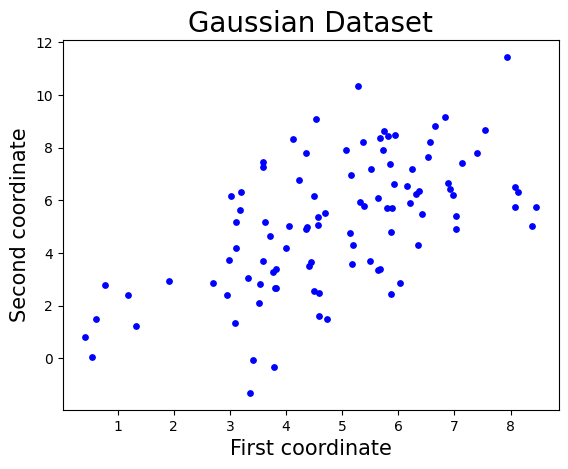

In [2]:
# Sample one dataset with (correlated) Gaussian distribution
np.random.seed(0)

# Size of data
n_samples = 100
n_dim = 2

# Mean vector of the dataset
mean = 5 *  np.ones(n_dim)

# Sample covariance matrix from a Wishart distribution
temp = np.random.randn(n_dim, n_dim)
cov = temp@temp.T

X = np.random.multivariate_normal(mean, cov, size=n_samples)

plt.scatter(X[:, 0], X[:, 1], s=15, c='b')
plt.xlabel('First coordinate', size=15)
plt.ylabel('Second coordinate', size=15)
plt.title('Gaussian Dataset', size=20)
plt.show()

### Question 1:

Implement your own PCA algorithm.

In [3]:
class MyPCA(object):

    def __init__(self, n_components):
        self.n_components = n_components


    def fit(self, X):
        cov_matrix = np.cov(X.T)
        np.linalg.eig(cov_matrix)
        eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

        #sort the eigenvalues in descending order
        sorted_index = np.flip(np.argsort(eigen_values))
        self.eigenvalues = eigen_values[sorted_index]

        self.eigenvalues = self.eigenvalues
        #similarly sort the eigenvectors
        self.eigenvectors = -1 * eigen_vectors[:,sorted_index]
        self.eigenvector_subset = self.eigenvectors[:, :self.n_components]


    def transform(self, Z):
        return np.dot(Z, self.eigenvector_subset)

### Question 2

Apply PCA on the Gaussian dataset

In [4]:
pca = MyPCA(2)
pca.fit(X)
X_new = pca.transform(X)

In [5]:
pca.eigenvectors

array([[ 0.49830062,  0.86700432],
       [ 0.86700432, -0.49830062]])

### Question 3

Verify that your transformed data are decorrelated. What do you observe?

In [6]:
np.cov(X_new.T)

array([[ 7.78619202e+00, -1.46523087e-15],
       [-1.46523087e-15,  1.67113936e+00]])

In [7]:
np.cov(X.T)

array([[3.18952838, 2.64187881],
       [2.64187881, 6.267803  ]])

The newly created features are very loosely correlated.

### Question 4

Visualize your transformed data after PCA.

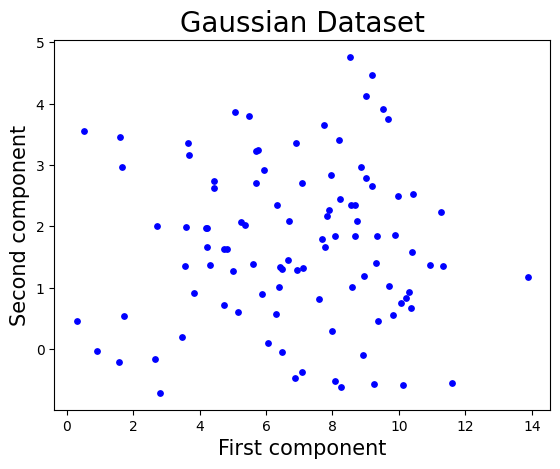

In [8]:

plt.scatter(X_new[:, 0], X_new[:, 1], s=15, c='b')
plt.xlabel('First component', size=15)
plt.ylabel('Second component', size=15)
plt.title('Gaussian Dataset', size=20)
plt.show()

### Question 4bis

Visualize PCA components in your original orthornormed reference frame (Plot the data, and the components-axes).

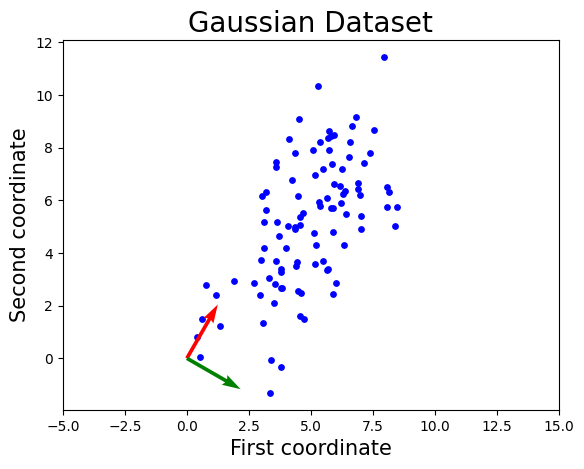

In [9]:
origin = np.array([[0, 0],[0, 0]])

V = pca.eigenvectors

plt.scatter(X[:, 0], X[:, 1], s=15, c='b')
plt.quiver(*origin, V[:,0], V[:,1], color=['r','g'], scale=8)
plt.xlabel('First coordinate', size=15)
plt.ylabel('Second coordinate', size=15)
plt.title('Gaussian Dataset', size=20)
plt.xlim(-5, 15)
plt.show()

### Question 5

Compare your algorithm with the one in sklearn. You can check the covariance matrix of the transformed data. Is this the same than yours? What do you observe?

In [10]:
from sklearn.decomposition import PCA

In [11]:
pca_new = PCA(2)
X_new_1 = pca_new.fit_transform(X)
np.cov(X_new_1.T)

array([[7.78619202e+00, 1.40284057e-16],
       [1.40284057e-16, 1.67113936e+00]])

The result is not exactly the same. This may due to the decimal taken when calculating Eigenvalues and vectors.

### Bonus Question

Compare the computational time of both algorithms, what do you observe? Why?

In [12]:
import time
seconds = time.time()
MyPCA(X)
seconds_1 = time.time()
print(seconds_1 - seconds)
PCA(X)
seconds_2 = time.time()
print(seconds_2 - seconds_1)

7.843971252441406e-05
0.0006206035614013672


In [13]:
seconds = time.time()
PCA(X)
seconds_2 = time.time()
print(seconds_2 - seconds)
MyPCA(X)
seconds_1 = time.time()
print(seconds_1 - seconds_2)


7.605552673339844e-05
0.0002276897430419922


two methods are about the same running time.

### Question 6

Let's apply the PCA on a (easy) classification real-world dataset. Apply PCA with 2 components and visualize the dataset with different colors for each class.

In [14]:
from sklearn import datasets

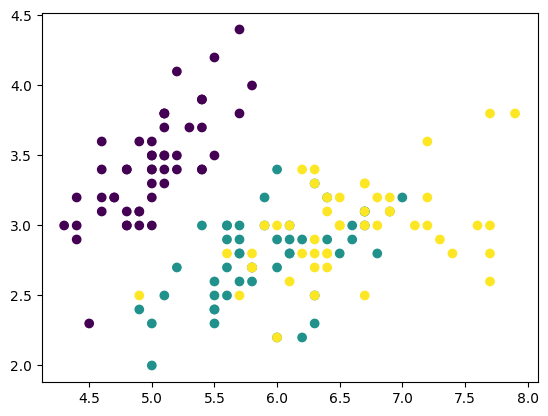

In [15]:
iris = datasets.load_iris()

X_iris = iris.data
y_iris = iris.target

plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris)
plt.show()

### Question 7

Use a KNN algorithm and perform it on the dataset. Use different combinations of parameters using the GridSearchCV function.

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [17]:
KNN = KNeighborsClassifier()
parameters = {"n_neighbors":[1,5,10,15,20], "weights" : ('uniform', 'distance')}
clf = GridSearchCV(KNN,parameters)
clf.fit(X_iris,y_iris)
sorted(clf.cv_results_.keys())

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_n_neighbors',
 'param_weights',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [18]:
clf.best_params_

{'n_neighbors': 10, 'weights': 'distance'}

### Question 8

Use a PCA first and then apply again the classification algorithm. Observe the best score, is the PCA improve the results? Which explanation can you give?

In [44]:
pca_new = PCA(3)
X_iris_new = pca_new.fit(X_iris).transform(X_iris)

In [45]:
parameters = {"n_neighbors":[1,5,10,15,20], "weights" : ('uniform', 'distance')}
clf_new = GridSearchCV(KNN,parameters)
clf_new.fit(X_iris_new,y_iris)
clf_new.best_params_

{'n_neighbors': 5, 'weights': 'uniform'}

In [46]:
print(clf.best_score_)
print(clf_new.best_score_)

0.9666666666666668
0.9733333333333334


The PCA improves the best score. this may due to X_iris has a big covariance among features.

### Question 9

How features influence the first components (in term of variance)? You can answer this question by inspecting the weights in the first component.

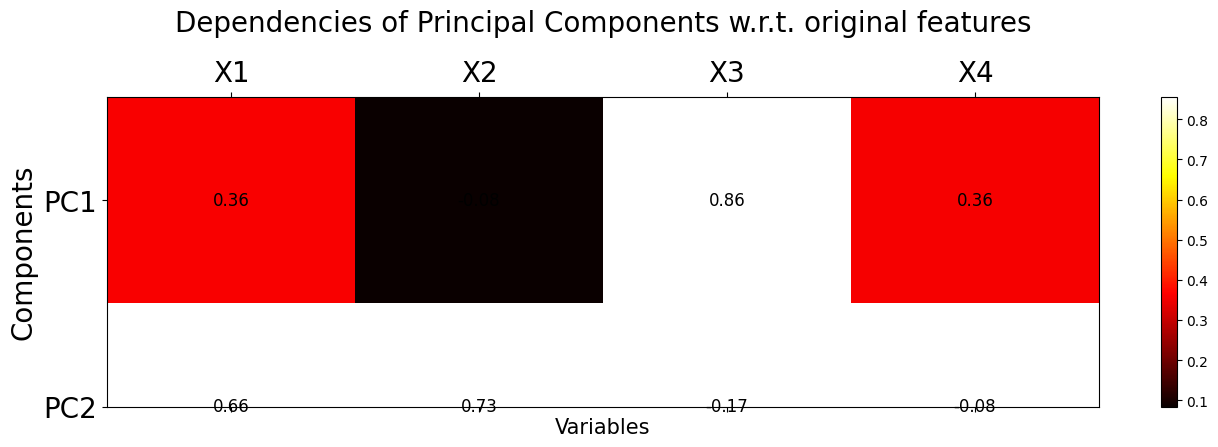

In [37]:
plt.matshow(np.abs(pca_new.components_[0:1, :]), cmap='hot', aspect='auto')
plt.ylabel('Components', size=20)
plt.xlabel('Variables', size=15)
for i in range(4):
    for j in range(2):
        plt.text(i, j, "%0.2f" % pca_new.components_[j, i], size=12, color='black', ha="center", va="center")
plt.colorbar()
xlabels = ['X1', 'X2', 'X3', 'X4']
plt.xticks(range(4), xlabels, size=20)
ylabels = ['PC1', 'PC2']
plt.yticks(range(2), ylabels, size=20)
plt.title('Dependencies of Principal Components w.r.t. original features', size=20, pad=20)
plt.show()

### Bonus Question

Create a pipeline with KNN, classification trees, RandomForest and SVM. Perform the Question 7/8 for these 4 classifiers. What do you observe?

In [40]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

dt_pipeline = Pipeline([('scaler', StandardScaler()),('dt', DecisionTreeClassifier())])
rf_pipeline = Pipeline([('scaler', StandardScaler()),('rf', RandomForestClassifier())])
svm_pipeline = Pipeline([('scaler', StandardScaler()),('svm', SVC())])

dt_parameters = {'dt__max_depth': [None, 5, 10, 15],'dt__min_samples_split': [2, 5, 10]}
rf_parameters = {'rf__n_estimators': [50, 100, 150],'rf__max_depth': [None, 5, 10]}
svm_parameters = {'svm__C': [0.1, 1, 10],'svm__kernel': ['linear', 'rbf']}

classifiers = [('Decision Trees', dt_pipeline, dt_parameters),('Random Forest', rf_pipeline, rf_parameters),('SVM', svm_pipeline, svm_parameters)]

for name, pipeline, parameters in classifiers:
    clf = GridSearchCV(pipeline, parameters)
    clf.fit(X_iris, y_iris)
    print(f"Results for {name}:")
    print("Best parameters:", clf.best_params_)
    print("Best score:", clf.best_score_)
    print()

Results for Decision Trees:
Best parameters: {'dt__max_depth': None, 'dt__min_samples_split': 2}
Best score: 0.9666666666666668

Results for Random Forest:
Best parameters: {'rf__max_depth': None, 'rf__n_estimators': 100}
Best score: 0.9666666666666668

Results for SVM:
Best parameters: {'svm__C': 10, 'svm__kernel': 'rbf'}
Best score: 0.9733333333333334



In [47]:
for name, pipeline, parameters in classifiers:
    clf = GridSearchCV(pipeline, parameters)
    clf.fit(X_iris_new, y_iris)
    print(f"Results for {name}:")
    print("Best parameters:", clf.best_params_)
    print("Best score:", clf.best_score_)
    print()

Results for Decision Trees:
Best parameters: {'dt__max_depth': None, 'dt__min_samples_split': 2}
Best score: 0.96

Results for Random Forest:
Best parameters: {'rf__max_depth': 10, 'rf__n_estimators': 150}
Best score: 0.9600000000000002

Results for SVM:
Best parameters: {'svm__C': 10, 'svm__kernel': 'linear'}
Best score: 0.9800000000000001



SVM has the highest score among all classifier. And PCA is effective in this case because it reduce the dimension of data and overfitting.

In [43]:
np.corrcoef(X_iris.T)

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

### Question 10

Time to apply PCA on a high dimensional dataset.

In [48]:
from sklearn.datasets import load_digits
digits = load_digits()
X_d = digits.data
y_d = digits.target

print(X_d.shape)

(1797, 64)


### Question 11

Now, you will have to reduce the dimension. The main question is: how to choose the number of components?


Perform a PCA with a high number of components and inspect the explained variance. Which number of components do you suggest?

In [51]:
pca = PCA(n_components=64)
X_pca = pca.fit_transform(X_d)
explained_variance_ratio = pca.explained_variance_ratio_

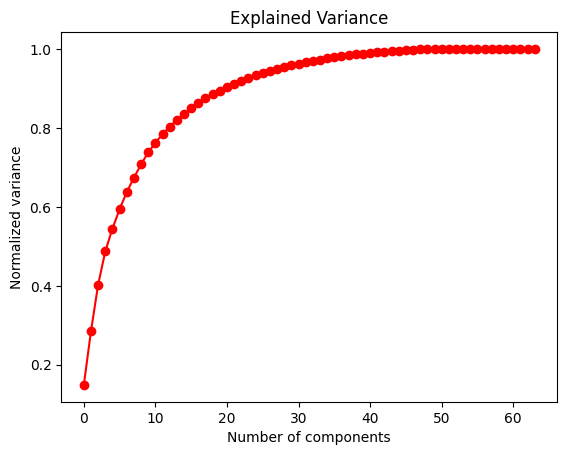

In [52]:
plt.plot(np.cumsum(explained_variance_ratio), marker='o', c='r')
plt.title('Explained Variance')
plt.ylabel('Normalized variance')
plt.xlabel('Number of components')
plt.show()

In [53]:
np.cumsum(explained_variance_ratio)

array([0.14890594, 0.28509365, 0.40303959, 0.48713938, 0.54496353,
       0.59413263, 0.6372925 , 0.67390623, 0.70743871, 0.73822677,
       0.76195018, 0.78467714, 0.80289578, 0.82063433, 0.83530534,
       0.84940249, 0.86258838, 0.87506976, 0.88524694, 0.89430312,
       0.9031985 , 0.91116973, 0.91884467, 0.9260737 , 0.93303259,
       0.9389934 , 0.94474955, 0.94990113, 0.95479652, 0.9590854 ,
       0.96282146, 0.96635421, 0.96972105, 0.97300135, 0.97608455,
       0.97902234, 0.98158823, 0.98386565, 0.98608843, 0.98820273,
       0.99010182, 0.99168835, 0.99319995, 0.99460574, 0.99577196,
       0.99684689, 0.99781094, 0.99858557, 0.99914278, 0.99954711,
       0.99975703, 0.99983951, 0.99989203, 0.99994255, 0.99997555,
       0.99998798, 0.99999503, 0.99999804, 0.99999911, 0.99999966,
       1.        , 1.        , 1.        , 1.        ])

We should choose n_component = 21, since the normalized variance is greater than 0.9, and the normalized variance increases slowly as number of component increases.

### Question 12

Run PCA on the handwritten digits data reducing its dimension from 64 to 2. Visualise digits in dimension two. Is dimension two seems enough to represent keep information of data?

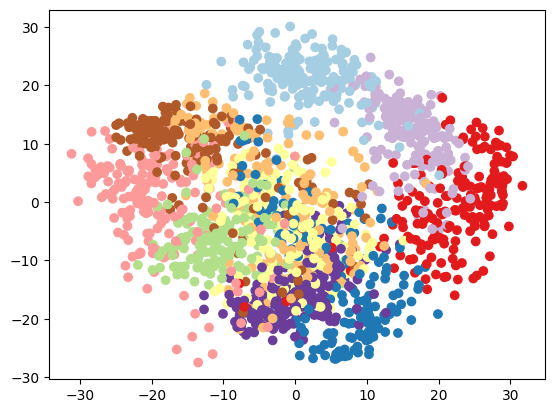

In [61]:
from matplotlib import cm
pca = PCA(2)
vis = pca.fit_transform(X_d)
colors = cm.Paired(np.linspace(0., 1., 10)) # list of 10 colors

colors_all = colors[digits.target]
plt.scatter(vis[:, 0], vis[:, 1], c=colors_all)
plt.show()

Two digits are not enough since it is unable to seperate the data digits.

### Question 13

Perform a KNN algorithm on the raw data and on the projected data. What do you observe in terms of accuracy?

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
print(knn.score(X_test, y_test))

pca = PCA(21)
X_pca = pca.fit_transform(X_d)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_d, test_size=0.2, random_state=42)
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train,y_train)
knn_pca.score(X_test, y_test)

0.9861111111111112


0.9861111111111112

by keeping reducing the number of componets to 21 from the origional dataset, the accuracy remain the same.

### Bonus Question

Apply other reduction dimension methods such as Kernel PCA (choose one kernel), Independant Component Analysis (ICA) and t-SNE. Visualize their projection in dimension two.

/usr/local/lib/python3.10/dist-packages/sklearn/decomposition/_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


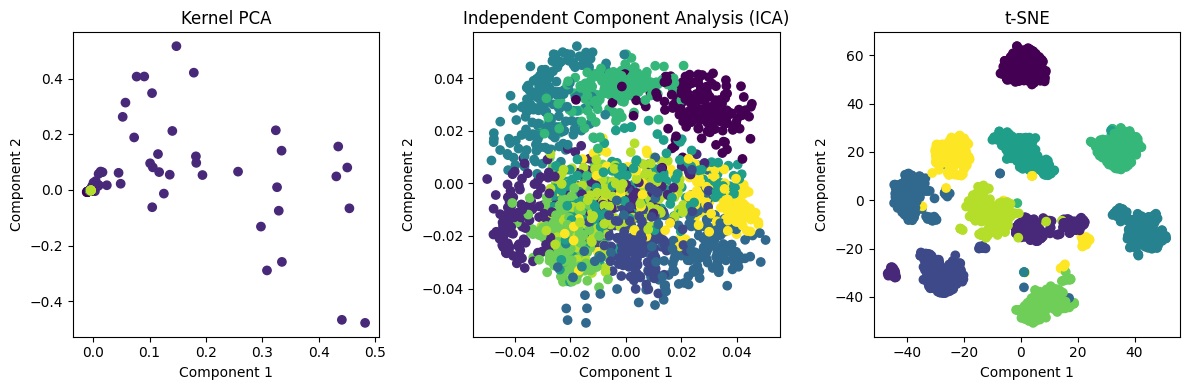

In [78]:
from sklearn.decomposition import FastICA, PCA, KernelPCA
from sklearn.manifold import TSNE

kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_d)

ica = FastICA(n_components=2)
X_ica = ica.fit_transform(X_d)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_d)

plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_d, cmap='viridis')
plt.title('Kernel PCA')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.subplot(132)
plt.scatter(X_ica[:, 0], X_ica[:, 1], c=y_d, cmap='viridis')
plt.title('Independent Component Analysis (ICA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.subplot(133)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_d, cmap='viridis')
plt.title('t-SNE')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.tight_layout()
plt.show()